In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 

# Basic, overall comparison:

Cell-line data:

In [2]:
gen1_rna = pd.read_csv("data/GSM7454075_V350003741_L01_88.txt", sep=" ")
gen1_rna.head()
## 28252 gene is present in all the transcriptomic files

,Gene,rpkm
0,A1BG,0.045642
1,A1BG-AS1,0.144942
2,A1CF,2.110224
3,A2M,0.012972
4,A2M-AS1,0.375840


In [3]:
cell_line_t = set(gen1_rna["Gene"])
len(cell_line_t)

28252

In [4]:
mapping = pd.read_csv("human_MHCC97H_gene_to_string_mapping.csv")
cell_line_t_mapped = set(mapping["#string_protein_id"])
len(cell_line_t_mapped)

19228

In [5]:
data = pd.read_csv("data/1-9DDA.csv")
data

,Protein IDs,Majority protein IDs,g-1,g-3,g-4,g-5,g-6,g-7,g-8,g-9
0,Biognosys|iRT-Kit_WR_fusion,Biognosys|iRT-Kit_WR_fusion,1.759900e+09,2.190600e+09,2.700000e+09,2.919500e+09,2.929400e+09,2.746800e+09,2.749800e+09,2.739200e+09
1,CON__A2A5Y0;CON__REFSEQ:XP_986630;sp|O76015|KR...,CON__A2A5Y0;CON__REFSEQ:XP_986630;sp|O76015|KR...,0.000000e+00,0.000000e+00,0.000000e+00,1.035500e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,CON__A2I7N1;CON__A2I7N0,CON__A2I7N1;CON__A2I7N0,9.384300e+06,7.737700e+06,8.645900e+06,1.363800e+07,7.774400e+06,1.313200e+07,3.876500e+06,3.803800e+06
3,CON__A2I7N3,CON__A2I7N3,1.321800e+06,3.147300e+06,1.298300e+06,6.730600e+06,2.073200e+06,3.600100e+06,1.614700e+06,5.319600e+06
4,CON__ENSEMBL:ENSBTAP00000001528;sp|Q15811|ITSN...,CON__ENSEMBL:ENSBTAP00000001528;sp|Q15811|ITSN...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...
5731,sp|Q9Y6Y0|NS1BP_HUMAN,sp|Q9Y6Y0|NS1BP_HUMAN,5.639500e+05,7.146100e+05,0.000000e+00,8.943900e+05,6.426200e+05,0.000000e+00,0.000000e+00,0.000000e+00
5732,sp|Q9Y6Y8|S23IP_HUMAN,sp|Q9Y6Y8|S23IP_HUMAN,5.718900e+06,5.683100e+06,7.192000e+06,4.491700e+06,4.680500e+06,5.076900e+06,3.266500e+06,7.789400e+06
5733,tr|B3KNS4|B3KNS4_HUMAN,tr|B3KNS4|B3KNS4_HUMAN,3.499400e+07,4.555700e+07,3.257200e+07,3.982800e+07,3.325000e+07,2.231400e+07,3.396600e+07,3.249400e+07
5734,tr|Q5TEC6|Q5TEC6_HUMAN,tr|Q5TEC6|Q5TEC6_HUMAN,3.716700e+09,2.771600e+09,2.120100e+09,2.258400e+09,1.576100e+09,2.463900e+09,1.716500e+09,2.386800e+09


In total 5736 measurements, after removing contaminated, reversed, non-human and technical measurements 5510 remains. The number of unique proteins is **5486** (there are peptides -- measurements mapping to the same protein). --> **5472** are mapped to STRING.

In [6]:
data_prot = pd.read_csv("data/1-9DDA_mapped.csv")
cell_line_p_mapped = set(data_prot["#string_protein_id"])
len(cell_line_p_mapped)

5472

In [7]:
len(cell_line_t_mapped), len(cell_line_p_mapped), len(cell_line_t_mapped&cell_line_p_mapped)

(19228, 5472, 5456)

In [8]:
(5456/5472)*100

99.70760233918129

**99.7% of proteins measured in the proteome are present in the transcriptome.**

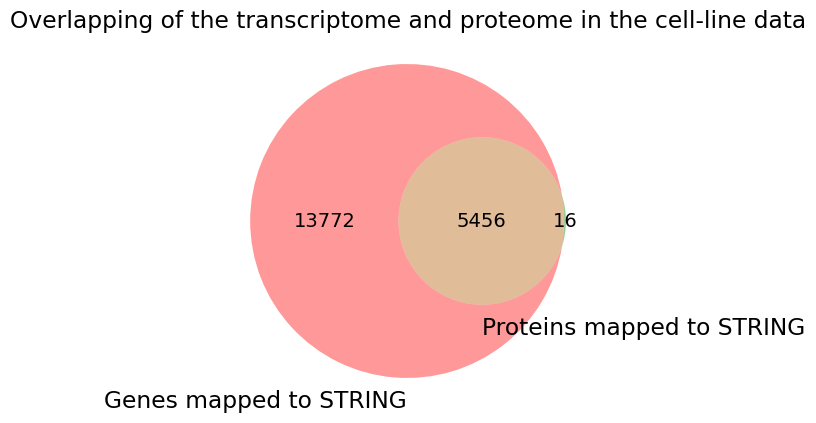

In [18]:
from matplotlib_venn import venn2
import matplotlib

venn2([cell_line_t_mapped, cell_line_p_mapped], ('Genes mapped to STRING', 'Proteins mapped to STRING'))
plt.title("Overlapping of the transcriptome and proteome in the cell-line data")
matplotlib.rcParams.update({'font.size': 14})

plt.savefig("figures/cell_line_overlap.pdf", bbox_inches='tight')

Embryo data:

In [11]:
import os 
files = os.listdir("data/GSE121160_RAW/")
files[0]

'GSM3427127_06h_4.tsv.gz'

In [12]:
for file in files:
    data = pd.read_csv("data/GSE121160_RAW/"+file, sep="\t", header=None)
    if len(data)!=17563:
        print(len(data))

In [13]:
data = pd.read_csv("data/GSE121160_RAW/"+files[0], sep="\t", header=None)
data.iloc[17558:]

,0,1
17558,no_feature,278529
17559,ambiguous,266420
17560,too_low_aQual,0
17561,not_aligned,0
17562,alignment_not_unique,424777


17558 genes are present in the data.

In [14]:
mapping = pd.read_csv("data/drosophila_m_gene_mapping.csv")
embryo_mapped_t = set(mapping["#string_protein_id"])
len(embryo_mapped_t)

13743

7387 measurements (rows) in the proteomics data, **6915** remains after filtering (reverse, contaminated, only identified by site,  identifiers in the measurement map do not map to the same protein). **6390** mapped to STRING **6221** unique proteins.

In [15]:
data_all = pd.read_csv("data/drosophila_m_lfq_mapped_to_string.csv")
embryo_mapped_p = set(data_all["#string_protein_id"])
len(embryo_mapped_p)

6221

In [16]:
len(embryo_mapped_t), len(embryo_mapped_p), len(embryo_mapped_t&embryo_mapped_p)

(13743, 6221, 6109)

In [21]:
(6109/6221)*100

98.19964635910625

**98.2% of proteins measured in the proteome are present in the transcriptome.**

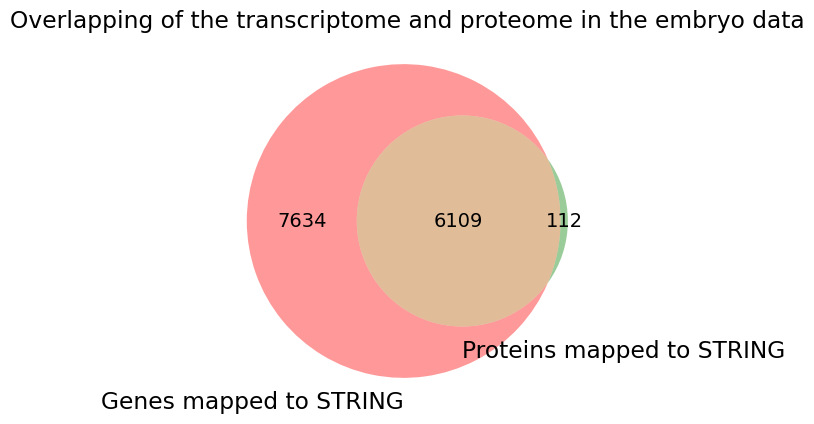

In [17]:
from matplotlib_venn import venn2

venn2([embryo_mapped_t, embryo_mapped_p], ('Genes mapped to STRING', 'Proteins mapped to STRING'))
plt.title("Overlapping of the transcriptome and proteome in the embryo data")
matplotlib.rcParams.update({'font.size': 14})

plt.savefig("figures/embryo_overlap.pdf", bbox_inches='tight')

___

# How much do the transcriptomic-based and proteomic-based networks overlap and does it change with time?

In [19]:
import networkx as nx
import scipy
import statsmodels.api as sm
from collections import defaultdict
from statannotations.Annotator import Annotator
from brokenaxes import brokenaxes
import matplotlib

Cell-line data:

In [32]:
files = os.listdir("network_data")

In [33]:
file_names = {1:"GSM7454068_V350003741_L01_81_0_network.csv", 2:"GSM7454069_V350003741_L01_82_0_network.csv",
              3:"GSM7454070_V350003741_L01_83_0_network.csv",
          4:"GSM7454071_V350003741_L01_84_0_network.csv", 5:"GSM7454072_V350003741_L01_85_0_network.csv",
              6:"GSM7454073_V350003741_L01_86_0_network.csv",
          7:"GSM7454074_V350003741_L01_87_0_network.csv", 8:"GSM7454075_V350003741_L01_88_0_network.csv",
              9:"GSM7454076_V350003741_L01_73_0_network.csv"}

file_names_protein = {1:"protein_g-1 _network.csv", 3:"protein_g-3_network.csv",
          4:"protein_g-4_network.csv", 5:"protein_g-5_network.csv",
              6:"protein_g-6_network.csv",
          7:"protein_g-7_network.csv", 8:"protein_g-8_network.csv",
              9:"protein_g-9_network.csv"}

In [34]:
overlap = pd.DataFrame()
for time in file_names_protein:
    network_df_t = pd.read_csv("network_data/"+file_names[time])
    g_t = nx.from_pandas_edgelist(network_df_t, source="protein1", target="protein2")
    network_df_p = pd.read_csv("network_data/"+file_names_protein[time])
    g_p = nx.from_pandas_edgelist(network_df_p, source="protein1", target="protein2")
    row = {"time":[time], "num_nodes_transcriptomics":[len(set(g_t.nodes()))],
          "num_nodes_proteomics":[len(set(g_p.nodes()))],
          "num_nodes_intersection":[len(set(g_t.nodes())&set(g_p.nodes()))]}
    overlap = pd.concat([overlap, pd.DataFrame(row)], ignore_index=True)

In [35]:
overlap["intersection_percentage"] = list(overlap["num_nodes_intersection"]/overlap["num_nodes_proteomics"])

map_time = {1:0, 3:1, 4:2, 5:3, 6:4, 7:5, 8:6, 9:7}
overlap["x"] = overlap["time"].map(map_time)

In [36]:
overlap

,time,num_nodes_transcriptomics,num_nodes_proteomics,num_nodes_intersection,intersection_percentage,x
0,1,6806,2607,2588,0.992712,0
1,3,6888,2598,2578,0.992302,1
2,4,6906,2619,2597,0.991600,2
3,5,6932,2539,2519,0.992123,3
4,6,6939,2567,2549,0.992988,4
5,7,6967,2615,2595,0.992352,5
6,8,6948,2613,2597,0.993877,6
7,9,6901,2588,2567,0.991886,7


/home/polyake/anaconda3/envs/agingnet/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
/home/polyake/anaconda3/envs/agingnet/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
/home/polyake/anaconda3/envs/agingnet/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in a

1 vs. 9: OLS coefficient = 4.76e-05 (n.s.)
 Spearman r = 0.095 (n.s.)


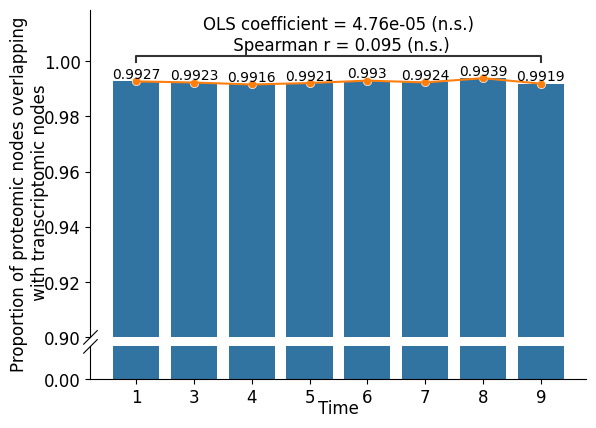

In [37]:
#plt.figure(figsize=(10,5))
matplotlib.rcParams.update({'font.size': 12})
bax = brokenaxes(
    ylims=((0, 0.01), (0.9, 1)),
    hspace=.05
)

for ax in bax.axs:
    sns.barplot(overlap["time"], round(overlap["intersection_percentage"],4), color="tab:blue", ax=ax)
    sns.scatterplot(overlap["x"], overlap["intersection_percentage"], color="tab:orange", ax=ax)
    sns.lineplot(overlap["x"], overlap["intersection_percentage"], color="tab:orange", ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel("")

    for container in ax.containers:
        ax.bar_label(container, fontsize=10)
        
bax.set_xlabel("Time")
bax.set_ylabel("Proportion of proteomic nodes overlapping\n with transcriptomic nodes")

pairs=[(1, 9)]
annot = Annotator(bax.axs[0], pairs, data=overlap, x="time", y="intersection_percentage")
annot.configure(test=None, text_format='full', fontsize=12)
annot.set_custom_annotations(["OLS coefficient = 4.76e-05 (n.s.)"+"\n Spearman r = 0.095 (n.s.)"])
annot.annotate()

plt.savefig("figures/cell_line_time_overlap.pdf", bbox_inches='tight')

In [82]:
X = sm.add_constant(overlap[["time"]])
reg = sm.regression.linear_model.OLS(overlap["intersection_percentage"], X)
results = reg.fit()
results.summary()

/home/polyake/anaconda3/envs/agingnet/lib/python3.8/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     intersection_percentage   R-squared:                       0.032
Model:                                 OLS   Adj. R-squared:                 -0.130
Method:                      Least Squares   F-statistic:                    0.1963
Date:                     Mon, 08 Jun 2026   Prob (F-statistic):              0.673
Time:                             17:17:34   Log-Likelihood:                 47.271
No. Observations:                        8   AIC:                            -90.54
Df Residuals:                            6   BIC:                            -90.38
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9922      0.001   1558.449      0.000       0.991       0.994
time         4.76e-05      0.000      0.443      0.673      -0.000       0.000
==============================================================================
Omnibus:                        0.847   Durbin-Watson:                   2.466
Prob(Omnibus):                  0.655   Jarque-Bera (JB):                0.521
Skew:                           0.535   Prob(JB):                        0.771
Kurtosis:                       2.354   Cond. No.                         14.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [83]:
scipy.stats.spearmanr(overlap["time"], overlap["intersection_percentage"])

SignificanceResult(statistic=0.09523809523809526, pvalue=0.8225054302036114)

In [84]:
scipy.stats.pearsonr(overlap["time"], overlap["intersection_percentage"])

PearsonRResult(statistic=0.1779863181381433, pvalue=0.6732567350410866)

Embryo data:

In [26]:
files = os.listdir("network_data/drosophila_m/")
t_files = defaultdict(list)
p_files = defaultdict(list)

for file in files:
    if "GSM" in file:
        age = int(file[11:-17])
        t_files[age].append(file)
    elif "protein" in file:
        age = int(file[8:-17])
        p_files[age].append(file)

In [27]:
overlap = pd.DataFrame()
for time in t_files.keys():
    for file in t_files[time]: 
        network_df_t = pd.read_csv("network_data/drosophila_m/"+file)
        g_t = nx.from_pandas_edgelist(network_df_t, source="protein1", target="protein2")
        for file_p in p_files[time]:
            network_df_p = pd.read_csv("network_data/drosophila_m/"+file_p)
            g_p = nx.from_pandas_edgelist(network_df_p, source="protein1", target="protein2")
            row = {"time":[time], "num_nodes_transcriptomics":[len(set(g_t.nodes()))],
                  "num_nodes_proteomics":[len(set(g_p.nodes()))],
                  "num_nodes_intersection":[len(set(g_t.nodes())&set(g_p.nodes()))]}
            overlap = pd.concat([overlap, pd.DataFrame(row)], ignore_index=True)

In [28]:
overlap["intersection_percentage"] = list(overlap["num_nodes_intersection"]/overlap["num_nodes_proteomics"])
overlap

,time,num_nodes_transcriptomics,num_nodes_proteomics,num_nodes_intersection,intersection_percentage
0,1,2761,1402,1340,0.955777
1,1,2761,1331,1273,0.956424
2,1,2761,1331,1273,0.956424
3,1,2761,1268,1212,0.955836
4,1,2753,1402,1340,0.955777
...,...,...,...,...,...
219,14,2905,1750,1675,0.957143
220,14,2889,1711,1641,0.959088
221,14,2889,1713,1641,0.957968
222,14,2889,1792,1723,0.961496


In [29]:
map_time = {0:0, 1:1, 2:2, 3:3, 4:4, 5:5, 6:6, 8:7, 10:8, 12:9, 14:10, 16:11, 18:12, 20:13}
overlap["x"] = overlap["time"].map(map_time)

/home/polyake/anaconda3/envs/agingnet/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
/home/polyake/anaconda3/envs/agingnet/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
/home/polyake/anaconda3/envs/agingnet/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in a

0 vs. 20: OLS coefficient = 0.0001
 Spearman r = 0.49


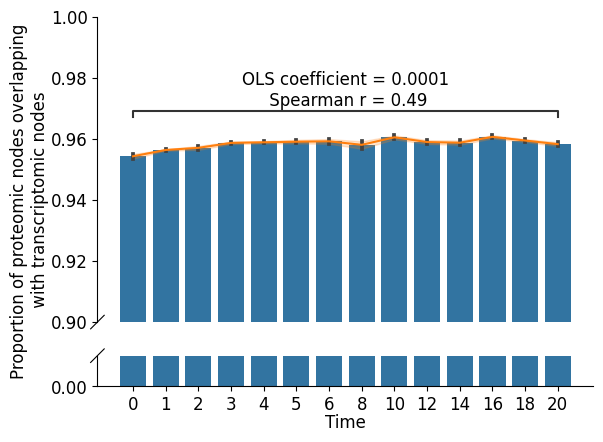

In [31]:
#plt.figure(figsize=(10,5))
matplotlib.rcParams.update({'font.size': 12})
bax = brokenaxes(
    ylims=((0, 0.01), (0.9, 1))
)

for ax in bax.axs:
    sns.barplot(overlap["time"], overlap["intersection_percentage"], color="tab:blue", ax=ax)
    sns.lineplot(overlap["x"], overlap["intersection_percentage"], color="tab:orange", ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel("")

bax.set_xlabel("Time", labelpad=20)
bax.set_ylabel("Proportion of proteomic nodes overlapping\n with transcriptomic nodes", labelpad=35)

pairs=[(0, 20)]
annot = Annotator(bax.axs[0], pairs, data=overlap, x="time", y="intersection_percentage")
annot.configure(test=None, text_format='full', fontsize=12)
annot.set_custom_annotations(["OLS coefficient = 0.0001"+"\n Spearman r = 0.49"])
annot.annotate()
plt.savefig("figures/embryo_time_overlap.pdf", bbox_inches='tight')

In [48]:
X = sm.add_constant(overlap[["time"]])
reg = sm.regression.linear_model.OLS(overlap["intersection_percentage"], X)
results = reg.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     intersection_percentage   R-squared:                       0.203
Model:                                 OLS   Adj. R-squared:                  0.199
Method:                      Least Squares   F-statistic:                     56.49
Date:                     Thu, 11 Jun 2026   Prob (F-statistic):           1.38e-12
Time:                             13:20:19   Log-Likelihood:                 1090.8
No. Observations:                      224   AIC:                            -2178.
Df Residuals:                          222   BIC:                            -2171.
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9572      0.000   4592.877      0.000       0.957       0.958
time           0.0001   1.96e-05      7.516      0.000       0.000       0.000
==============================================================================
Omnibus:                        7.407   Durbin-Watson:                   1.191
Prob(Omnibus):                  0.025   Jarque-Bera (JB):                7.320
Skew:                          -0.438   Prob(JB):                       0.0257
Kurtosis:                       3.124   Cond. No.                         17.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [49]:
results.params

const    0.957164
time     0.000148
dtype: float64

In [50]:
results.pvalues

const    0.000000e+00
time     1.378970e-12
dtype: float64

<Axes: xlabel='time', ylabel='intersection_percentage'>

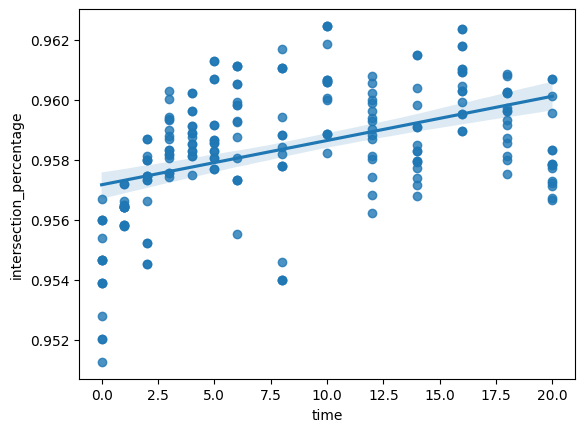

In [245]:
sns.regplot(x=overlap["time"], y=overlap["intersection_percentage"])

In [249]:
scipy.stats.spearmanr(overlap["time"], overlap["intersection_percentage"])

SignificanceResult(statistic=0.48807721193267706, pvalue=8.25872900981769e-15)

In [250]:
scipy.stats.pearsonr(overlap["time"], overlap["intersection_percentage"])

PearsonRResult(statistic=0.4503664151977772, pvalue=1.3789697180169459e-12)